This notebook begins the modeling phase of our Facebook Metrics project.
All preprocessing steps have already been completed in preprocessing.ipynb, including:

Handling missing values , removing redundant / highly correlated columns, encoding categorical variables, scaling numerical features, saving the cleaned dataset to processed/facebook_cleaned.csv

In this notebook, we will:

- Load the cleaned dataset
- Define our target variable (y) and features (X)
- Create a train/test split
- Train a baseline model
- Evaluate performance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
#Loading the cleaned dataset

data = pd.read_csv("../processed/facebook_cleaned.csv")

In [3]:
data.columns

Index(['Lifetime Post Total Reach', 'Lifetime Engaged Users',
       'Lifetime Post Consumers',
       'Lifetime Post Impressions by people who have liked your Page',
       'Lifetime Post reach by people who like your Page',
       'Lifetime People who have liked your Page and engaged with your post',
       'comment', 'like', 'share', 'Type_Photo', 'Type_Status', 'Type_Video',
       'Category_2', 'Category_3', 'Post Month_2', 'Post Month_3',
       'Post Month_4', 'Post Month_5', 'Post Month_6', 'Post Month_7',
       'Post Month_8', 'Post Month_9', 'Post Month_10', 'Post Month_11',
       'Post Month_12', 'Post Weekday_2', 'Post Weekday_3', 'Post Weekday_4',
       'Post Weekday_5', 'Post Weekday_6', 'Post Weekday_7', 'Post Hour_2',
       'Post Hour_3', 'Post Hour_4', 'Post Hour_5', 'Post Hour_6',
       'Post Hour_7', 'Post Hour_8', 'Post Hour_9', 'Post Hour_10',
       'Post Hour_11', 'Post Hour_12', 'Post Hour_13', 'Post Hour_14',
       'Post Hour_15', 'Post Hour_16', 'Post Ho

In [4]:
#Train/ Test Split 
#We chose 'like' because 'like' is the most stable/ computable metric to evaluate. 


X = data.drop(columns=['like'])
y = data['like']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#Our supervised model is trying to predict the number of likes a Facebook post receives based on all the other features (reach & impression features, comments, shares, post type, and post metadata features).

## **Random Forest Regressor Model**

In [5]:
#We use RandomForestRegressor model first as a baseline because our data has mixed feature types and our variable 'like' is a nonlinear feature.

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [6]:
#Then Evaluate

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)


MAE: 0.19444093780244479
RMSE: 0.4610121390176264
R^2: 0.5164342223779319


*Results*

Our results show us how well does the model predict the number of likes a post will get. 
MAE: 0.1944 , on average our model's predictions are off by 0.19 units of our target variable. Our model then is reasonably accurate but not perfect.

RMSE: 0.4610 , model occassionally can ,ale larger errors than the MAE suggests. Some posts may be harder to predit or there may be outliers or unusal posts (viral posts, paid videos, paid posts, etc.)

R^2: 0.5164 , shows us how much variation our target variable model can explain. Which is about half of the variation in likes. 

## **K-Means Clustering**

To complement our supervised modeling, we apply an unsupervised technique — "K-Means clustering" — to uncover natural groupings within our Facebook posts. Clustering helps us understand structural patterns in engagement and reach metrics that are not directly visible from the raw data. Unlike dimensionality reduction, clustering produces meaningful grouping labels that we can add back into our dataset as a new feature. Dimensionality reduction compresses features, but does not create useful features for modeling. These cluster labels may improve the performance of our supervised models by giving them additional information about underlying groups.

In [7]:
#Import additional packages

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#Selected Features for Clustering
cluster_features = [
    'Lifetime Post Total Reach',
    'Lifetime Engaged Users',
    'Lifetime Post Consumers',
    'Lifetime Post Impressions by people who have liked your Page',
    'Lifetime Post reach by people who like your Page',
    'Lifetime People who have liked your Page and engaged with your post',
    'comment',
    'share'
]

X_cluster = data[cluster_features]

#Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)


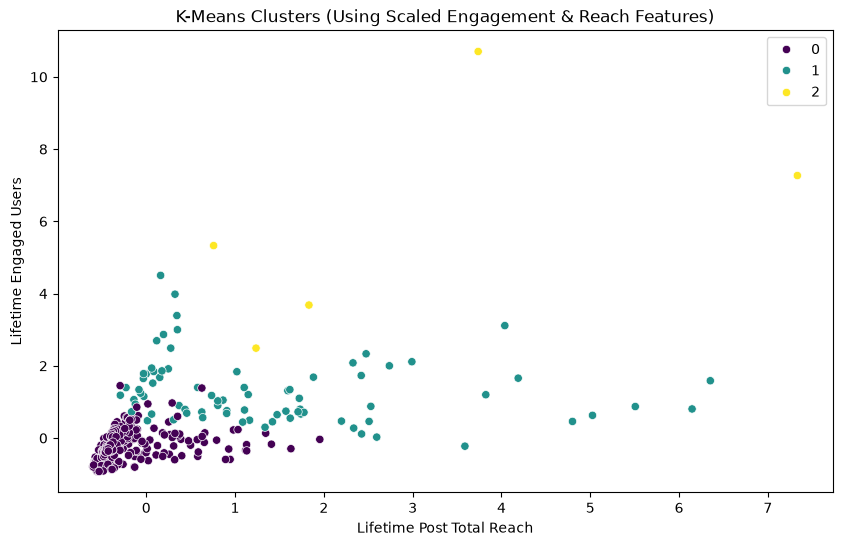

In [8]:
#Apply K-means
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
data['cluster'] = clusters

#Visualization 
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=clusters,
    palette='viridis'
)
plt.title("K-Means Clusters (Using Scaled Engagement & Reach Features)")
plt.xlabel(cluster_features[0])
plt.ylabel(cluster_features[1])
plt.show()

In [9]:

print(data['cluster'].value_counts()) #Gives us an accurate total of the cluster distribution
data.groupby('cluster')[cluster_features].mean() #Interpreting what each cluster represents

cluster
0    417
1     78
2      5
Name: count, dtype: int64


,Lifetime Post Total Reach,Lifetime Engaged Users,Lifetime Post Consumers,Lifetime Post Impressions by people who have liked your Page,Lifetime Post reach by people who like your Page,Lifetime People who have liked your Page and engaged with your post,comment,share
cluster,,,,,,,,
0,-0.296477,-0.310545,540.925659,7556.868106,3991.894484,405.398082,-0.134072,-0.153759
1,1.394030,1.282391,1878.743590,56245.512821,18972.666667,1555.615385,0.295920,0.473422
2,2.979300,5.894179,5455.600000,168964.800000,29651.200000,2920.800000,6.565210,5.438105


*Results*

K‑Means found three natural groups in our data based on: Lifetime Reach, Engaged Users, Consumers , Impressions, Follower Reach , People who engaged, Comments, Shares

cluster

0 ->  417 , mostly low reach/ low engagement posts (purple) - Normal posts

1 ->  78 , a little higher reach or engagement and more spread (green) - Above Average posts

2  ->  5, Highest reach/ engagement (which seem to be the outliers, yellow) - Amazing "viral" posts

Clustering gave us a way to better segment our posts into meaningful behavioral groups. It aided in revealing which posts are typical, which perform well, and which ones likely go viral. The cluster labels can now act as new feature that our supervised modeals can learn from and improve accuracy because our models can now better predict which "type" of post its predicting. 

## **Supplementary Model: Multiple Linear Regression (Offers Interpretability)**

Although our primary supervised model predicts `likes` using a nonlinear algorithm (Random Forest), we included a Multiple Linear Regression (MLR) model as a supplementary interpretability tool. Earlier EDA showed that Facebook engagement metrics are nonlinear, skewed, and influenced by viral outliers, making MLR less suitable as the primary predictive model for this dataset. However, it still provides coefficient-level insight into how selected features directionally relate to engagement.

To make the regression more stable, we used `Lifetime Engaged Users` as the target instead of `like` because it is more continuous and less zero-inflated. This allows the model to produce interpretable coefficients even though some model assumptions are violated.

---

## **Interpretation of Assumption Violations**

The diagnostic results indicate that linear regression is not the strongest predictive approach for this dataset. However, the model still provides exploratory directional insight into the relationships between selected features and engagement.

---

## **Regression Results**

### **Model Fit**
- **R²:** 0.48  
- **Adjusted R²:** 0.47  

The model explains ~48% of the variance in engaged users — reasonable for interpretability, but weaker than our Random Forest model.

---

## Coefficient Interpretation Table

| **Feature** | **Coefficient** | **Interpretation** |
|-------------|-----------------|---------------------|
| Lifetime Post Total Reach | 0.58 | Increasing reach is the strongest driver of engagement. |
| Type_Status | 1.76 | Status posts generate significantly higher engagement. |
| Type_Photo | 0.57 | Photo posts also increase engagement. |
| Type_Video | 0.53 | Videos contribute positively but less strongly. |
| Paid_1.0 | 0.10 | Paid promotion does not significantly increase engagement. |
| Category_2 / Category_3 | ~0.10 | Content category has mild directional influence. |

---

## **Alignment With Earlier EDA Findings**

- **Reach** is the strongest predictor of engagement.  
- **Content format** matters more than promotion.  
- **Viral posts** distort variance and normality, causing assumption violations.



**Multiple Linear Regression and Assumptions of Mulitple Linear Regression**

1. Absence of Multicollinearity: Predictors must not be highly correlated with one another (VIF<5.0).All feature VIF scores are below 3.2 (Type_Status: 3.18, Type_Photo: 3.15, Reach: 1.08), confirming that feature selection successfully eliminated redundant signals without introducing severe multi-collinearity.
2. Homoscedasticity (Constant Variance): Residual variance should remain constant across all predicted values.The Breusch-Pagan test yields p<0.001, rejecting the null hypothesis of equal variance. As seen in Plot 1, residual variance expands slightly at higher predicted engagement levels, driven by viral posts.
3. Normality of Residuals: Residual error terms should follow a normal distribution N(0,2).The Shapiro-Wilk test yields p<0.001, and the Q-Q plot (Plot 2) shows deviation in the upper theoretical quantiles. This is typical for social media engagement metrics due to extreme outlier spikes (viral posts).
To fix the violations of homoscedasticity and normality:Apply a log transformation ((Y+1)) to Lifetime Engaged Users prior to fitting the OLS model to compress viral outlier spikes and stabilize residual variance.



In [10]:

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
import scipy.stats as stats
import statsmodels.api as sm


# Define target (Y) and features (X)
target = 'Lifetime Engaged Users'
features = ['Lifetime Post Total Reach', 'Type_Photo', 'Type_Status', 'Type_Video', 'Category_2', 'Category_3', 'Paid_1.0']

X = data[features].astype(float)
X_const = sm.add_constant(X)
y = data[target]

# Fit Ordinary Least Squares (OLS) model
model = sm.OLS(y, X_const).fit()
residuals = model.resid
fitted = model.fittedvalues

# 1. Multicollinearity (VIF)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]

# 2. Homoscedasticity (Breusch-Pagan Test)
bp_test = het_breuschpagan(residuals, model.model.exog)
bp_pvalue = bp_test[1]

# 3. Normality of Residuals (Jarque-Bera & Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("--- VIF Scores ---")
print(vif_data)
print(f"\nBreusch-Pagan Test p-value: {bp_pvalue:.4e}")
print(f"Shapiro-Wilk Test p-value: {shapiro_p:.4e}")

# Save diagnostic visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot 1: Linearity / Residuals vs Fitted
axes[0, 0].scatter(fitted, residuals, alpha=0.5, color='blue')
axes[0, 0].axhline(y=0, color='red', linestyle='--')
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")
axes[0, 0].set_title("1. Linearity & Homoscedasticity (Residuals vs Fitted)")

# Plot 2: Q-Q Plot (Normality)
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("2. Normality of Residuals (Q-Q Plot)")

# Plot 3: Residuals Histogram
axes[1, 0].hist(residuals, bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("3. Distribution of Residuals")

# Plot 4: VIF Bar Chart
vif_no_const = vif_data[vif_data["Feature"] != "const"]
axes[1, 1].barh(vif_no_const["Feature"], vif_no_const["VIF"], color='skyblue', edgecolor='black')
axes[1, 1].axvline(x=5, color='red', linestyle='--', label='VIF Threshold = 5')
axes[1, 1].set_xlabel("VIF Score")
axes[1, 1].set_title("4. Multicollinearity Check (VIF Scores)")
axes[1, 1].legend()

plt.tight_layout()
plt.savefig("mlr_assumptions_diagnostic.png")
plt.close()

ModuleNotFoundError: No module named 'statsmodels'


The multiple linear regression analysis explains approximately 48% of the variance in Facebook user engagement, revealing that specific content formats are the primary drivers of success.Expanding a post's total audience reach is the single most reliable way to increase total engaged users.Text-based status updates and photo posts generate significantly higher engagement. Paying to promote a post does not significantly increase the likelihood that a user will actually engage with the content.



In [ ]:

# Define target (Y) and predictors (X)
# Target: Lifetime Engaged Users
# Predictors: Lifetime Post Total Reach, Type_Photo, Type_Status, Type_Video, Category_2, Category_3, Paid_1.0
target = 'Lifetime Engaged Users'
features = ['Lifetime Post Total Reach', 'Type_Photo', 'Type_Status', 'Type_Video', 'Category_2', 'Category_3', 'Paid_1.0']

X = data[features].astype(float)
X = sm.add_constant(X)
y = data[target]

model = sm.OLS(y, X).fit()

# Print summary
print("R-squared:", model.rsquared)
print("Adj R-squared:", model.rsquared_adj)
print("\nCoefficients:")
print(model.params)
print("\nP-values:")
print(model.pvalues)

# Diagnostic plot: Actual vs Predicted
y_pred = model.predict(X)
residuals = y - y_pred

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_pred, y, alpha=0.5, color='b')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Predicted Engaged Users')
plt.ylabel('Actual Engaged Users')
plt.title('Actual vs Predicted')

plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5, color='purple')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Engaged Users')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.savefig("mlr_results.png")
plt.close()

R-squared: 0.4797251171035465
Adj R-squared: 0.47232283218428806

Coefficients:
const                       -0.745796
Lifetime Post Total Reach    0.583611
Type_Photo                   0.567957
Type_Status                  1.760000
Type_Video                   0.526350
Category_2                   0.132943
Category_3                   0.103492
Paid_1.0                     0.106044
dtype: float64

P-values:
const                        2.495350e-06
Lifetime Post Total Reach    2.031949e-52
Type_Photo                   5.136423e-04
Type_Status                  5.793526e-17
Type_Video                   1.001194e-01
Category_2                   1.414387e-01
Category_3                   1.908433e-01
Paid_1.0                     1.499083e-01
dtype: float64


## **In Conclusion**

Together, the three models examine Facebook engagement from complementary perspectives. The Random Forest Regressor captured nonlinear relationships while explaining approximately 51% of the variation in standardized likes. K-Means identified three distinct post-performance groups: normal, above-average, and viral posts. The supplementary MLR provided exploratory insight into how reach and post format relate to engaged users, although assumption violations require cautious interpretation.

These analyses collectively demonstrate that Facebook engagement is nonlinear, strongly associated with reach and content format, and influenced by a small number of extreme viral posts.


In [13]:
#Adding clustering labels (columns) for later visualizations to save in an new csv labled `final_model.csv`

data['cluster'] = clusters

def label_cluster(x):
    if x == 0:
        return "Normal"
    elif x == 1:
        return "Above Average"
    else:
        return "Viral"

data['cluster_label'] = data['cluster'].apply(label_cluster)

# Adding scaled features if for later visualizations if scatterplot will be recreated with Tableau
data['scaled_feature_1'] = X_scaled[:, 0]
data['scaled_feature_2'] = X_scaled[:, 1]

# Exporting final dataset for Tableau
data.to_csv("../Data/facebook+metrics/final_model.csv", index=False)